# Step 1 — Loading and Visualising Real Stellar Light Curve Data

## Exoplanet Transit Detection Pipeline

### Objective

The first stage of this project is to obtain real observations from space telescopes and visualise the brightness variation of a star over time.

In this notebook I will:

1. Access real Kepler Space Telescope observations
2. Download stellar brightness measurements
3. Inspect the raw data structure
4. Plot the raw stellar light curve
5. Save the figure for later analysis

The output of this stage is a raw light curve that will later be cleaned and analysed for possible exoplanet transit signals.

---

## Scientific Background

A light curve is a measurement of a star's brightness as a function of time.

When an exoplanet passes between its host star and the observer, it blocks a small fraction of the stellar light.

This produces a characteristic dip:


In [3]:
# Import required libraries

import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Searching for Telescope Data

I have used the `lightkurve` Python package to access publicly available observations from NASA missions.

For this first example I used:

**Target: Kepler-10**

Kepler-10 is a Sun-like star observed by the Kepler Space Telescope.

The Kepler mission measured stellar brightness with extremely high precision to search for planets using the transit method.

In [5]:
# Search the Kepler archive for observations of Kepler-10

search_result = lk.search_lightcurve(
    "Kepler-10",
    mission="Kepler"
)

search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 02,2009,Kepler,60,kplr011904151,0.0
1,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
2,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
3,Kepler Quarter 03,2009,Kepler,60,kplr011904151,0.0
4,Kepler Quarter 00,2009,Kepler,1800,kplr011904151,0.0
5,Kepler Quarter 01,2009,Kepler,1800,kplr011904151,0.0
6,Kepler Quarter 02,2009,Kepler,1800,kplr011904151,0.0
7,Kepler Quarter 03,2009,Kepler,1800,kplr011904151,0.0
8,Kepler Quarter 04,2010,Kepler,60,kplr011904151,0.0


The search result contains information about available observations.

Important columns include:

- Mission name
- Observation quarter
- Cadence
- Data products available

Kepler observations are divided into quarters because the spacecraft orientation was periodically changed.

In [6]:
# Download the first available light curve

lc = search_result.download()

lc

/Users/soSophiephiemainprize/miniforge3/lib/python3.12/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 50 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
200.32408500967722,5.5696000e+05,1.1305735e+02,0,2.622170e-03,655.63318,250.32889,122650,5.5629538e+05,1.1105357e+02,3.4163665e+03,6.7321736e-01,5.5696000e+05,1.1305735e+02,0,———,———,———,———,655.63318,2.0087537e-04,250.32889,2.8624298e-04,-8.9440849e-03,3.7062202e-02
200.3247661127025,5.5708588e+05,1.1307109e+02,0,2.622173e-03,655.63361,250.32593,122651,5.5642056e+05,1.1106165e+02,3.4168267e+03,6.7319971e-01,5.5708588e+05,1.1307109e+02,0,———,———,———,———,655.63361,2.0079174e-04,250.32593,2.8616333e-04,-8.9426376e-03,3.7056953e-02
200.32544721572776,5.5703188e+05,1.1307073e+02,0,2.622176e-03,655.63319,250.32772,122652,5.5636775e+05,1.1105553e+02,3.4172874e+03,6.7318219e-01,5.5703188e+05,1.1307073e+02,0,———,———,———,———,655.63319,2.0085592e-04,250.32772,2.8623262e-04,-8.9411894e-03,3.7051704e-02
200.32612831898587,5.5684444e+05,1.1306761e+02,0,2.622179e-03,655.63277,250.32793,122653,5.5618300e+05,1.1104655e+02,3.4177478e+03,6.7316467e-01,5.5684444e+05,1.1306761e+02,0,———,———,———,———,655.63277,2.0090178e-04,250.32793,2.8624505e-04,-8.9397421e-03,3.7046455e-02
200.3268094220184,5.5680788e+05,1.1306657e+02,0,2.622182e-03,655.63314,250.32734,122654,5.5614750e+05,1.1103952e+02,3.4182083e+03,6.7314714e-01,5.5680788e+05,1.1306657e+02,0,———,———,———,———,655.63314,2.0090664e-04,250.32734,2.8633900e-04,-8.9382939e-03,3.7041202e-02
200.3274905250437,5.5690000e+05,1.1308340e+02,0,2.622185e-03,655.63494,250.32809,122655,5.5623925e+05,1.1105020e+02,3.4186687e+03,6.7312962e-01,5.5690000e+05,1.1308340e+02,0,———,———,———,———,655.63494,2.0091342e-04,250.32809,2.8628414e-04,-8.9368466e-03,3.7035953e-02
200.32817172830255,5.5693525e+05,1.1309309e+02,10000000000000,2.622188e-03,655.63234,250.32742,122656,5.5627475e+05,1.1105363e+02,3.4191294e+03,6.7311198e-01,5.5693525e+05,1.1309309e+02,10000000000000,———,———,———,———,655.63234,2.0093309e-04,250.32742,2.8624979e-04,-8.9353984e-03,3.7030704e-02
200.32885283132782,5.5703019e+05,1.1310329e+02,0,2.622191e-03,655.63383,250.32734,122657,5.5636931e+05,1.1105746e+02,3.4195896e+03,6.7309445e-01,5.5703019e+05,1.1310329e+02,0,———,———,———,———,655.63383,2.0092484e-04,250.32734,2.8618125e-04,-8.9339502e-03,3.7025455e-02


## 2. Inspecting the Light Curve

The light curve contains two main quantities:

### Time

The observation time of each measurement.

### Flux

The measured brightness of the star.

Flux is normally expressed relative to the average stellar brightness.

A value of:


In [8]:
# Display the first few observations

lc.to_table()

time,flux,flux_err,quality,timecorr,centroid_col,centroid_row,cadenceno,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,sap_quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,electron / s,electron / s,,d,pix,pix,,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,int32,float32,float64,float64,int32,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
200.32408500967722,5.5696000e+05,1.1305735e+02,0,2.622170e-03,655.63318,250.32889,122650,5.5629538e+05,1.1105357e+02,3.4163665e+03,6.7321736e-01,5.5696000e+05,1.1305735e+02,0,--,--,--,--,655.63318,2.0087537e-04,250.32889,2.8624298e-04,-8.9440849e-03,3.7062202e-02
200.3247661127025,5.5708588e+05,1.1307109e+02,0,2.622173e-03,655.63361,250.32593,122651,5.5642056e+05,1.1106165e+02,3.4168267e+03,6.7319971e-01,5.5708588e+05,1.1307109e+02,0,--,--,--,--,655.63361,2.0079174e-04,250.32593,2.8616333e-04,-8.9426376e-03,3.7056953e-02
200.32544721572776,5.5703188e+05,1.1307073e+02,0,2.622176e-03,655.63319,250.32772,122652,5.5636775e+05,1.1105553e+02,3.4172874e+03,6.7318219e-01,5.5703188e+05,1.1307073e+02,0,--,--,--,--,655.63319,2.0085592e-04,250.32772,2.8623262e-04,-8.9411894e-03,3.7051704e-02
200.32612831898587,5.5684444e+05,1.1306761e+02,0,2.622179e-03,655.63277,250.32793,122653,5.5618300e+05,1.1104655e+02,3.4177478e+03,6.7316467e-01,5.5684444e+05,1.1306761e+02,0,--,--,--,--,655.63277,2.0090178e-04,250.32793,2.8624505e-04,-8.9397421e-03,3.7046455e-02
200.3268094220184,5.5680788e+05,1.1306657e+02,0,2.622182e-03,655.63314,250.32734,122654,5.5614750e+05,1.1103952e+02,3.4182083e+03,6.7314714e-01,5.5680788e+05,1.1306657e+02,0,--,--,--,--,655.63314,2.0090664e-04,250.32734,2.8633900e-04,-8.9382939e-03,3.7041202e-02
200.3274905250437,5.5690000e+05,1.1308340e+02,0,2.622185e-03,655.63494,250.32809,122655,5.5623925e+05,1.1105020e+02,3.4186687e+03,6.7312962e-01,5.5690000e+05,1.1308340e+02,0,--,--,--,--,655.63494,2.0091342e-04,250.32809,2.8628414e-04,-8.9368466e-03,3.7035953e-02
200.32817172830255,5.5693525e+05,1.1309309e+02,10000000000000,2.622188e-03,655.63234,250.32742,122656,5.5627475e+05,1.1105363e+02,3.4191294e+03,6.7311198e-01,5.5693525e+05,1.1309309e+02,10000000000000,--,--,--,--,655.63234,2.0093309e-04,250.32742,2.8624979e-04,-8.9353984e-03,3.7030704e-02
200.32885283132782,5.5703019e+05,1.1310329e+02,0,2.622191e-03,655.63383,250.32734,122657,5.5636931e+05,1.1105746e+02,3.4195896e+03,6.7309445e-01,5.5703019e+05,1.1310329e+02,0,--,--,--,--,655.63383,2.0092484e-04,250.32734,2.8618125e-04,-8.9339502e-03,3.7025455e-02


## 3. Plotting the Raw Light Curve

Before cleaning the data, I first examined the raw measurements.

The raw light curve contains:

- Stellar variability
- Instrumental effects
- Measurement noise
- Possible transit signals

At this stage I did not remove anything.

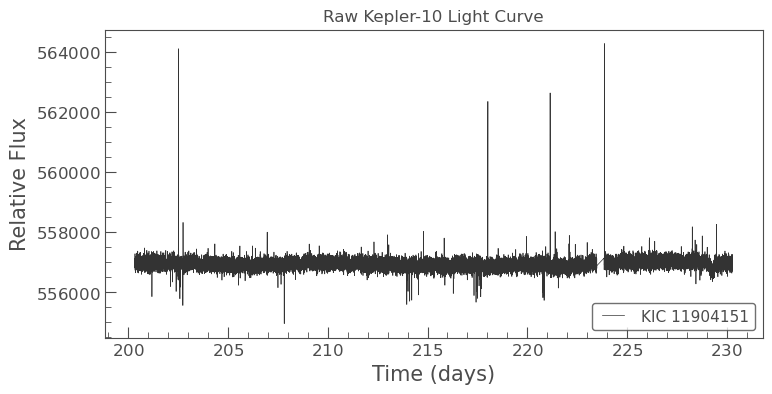

In [9]:
# Plot raw stellar brightness versus time

ax = lc.plot()

plt.title("Raw Kepler-10 Light Curve")

plt.xlabel("Time (days)")

plt.ylabel("Relative Flux")

plt.show()

## 4. Saving the Figure

Scientific workflows should produce reproducible outputs.

The raw light curve figure is saved so it can later be included in:

- The GitHub README
- The project report
- Scientific documentation

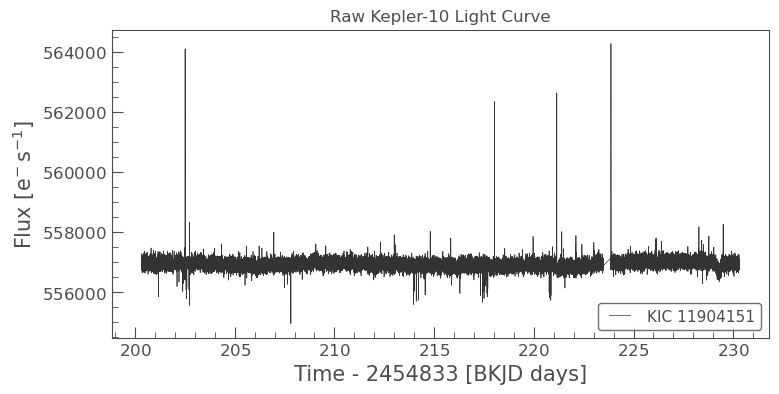

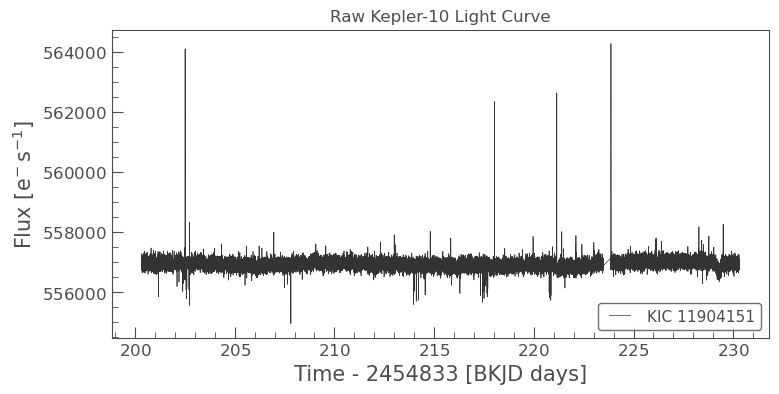

In [8]:
# Save figure

ax = lc.plot()

plt.title("Raw Kepler-10 Light Curve")

plt.savefig(
    "../figures/raw_lightcurve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. Basic Data Exploration

Before moving to cleaning, I inspected:

- Number of measurements
- Observation times
- Flux range

This helps to understand the dataset before processing.

In [11]:
# Number of measurements

print("Number of observations:", len(lc.flux))


# Time range

print("Start time:", lc.time.min())

print("End time:", lc.time.max())


# Flux statistics

# Convert flux to a normal NumPy array
flux_values = lc.flux.value

# Remove missing values
flux_values = flux_values[~np.isnan(flux_values)]

# Print statistics
print("Minimum flux:", np.min(flux_values))
print("Maximum flux:", np.max(flux_values))
print("Mean flux:", np.mean(flux_values))
print("Standard deviation:", np.std(flux_values))

Number of observations: 43363
Start time: 200.32408500967722
End time: 230.29940224067832
Minimum flux: 554957.1
Maximum flux: 564278.94
Mean flux: 556936.0
Standard deviation: 152.18935


# Summary

## Completed Tasks

✓ Connected to NASA Kepler archive  
✓ Downloaded real stellar observations  
✓ Loaded light curve data into Python  
✓ Inspected the dataset structure  
✓ Produced a raw stellar brightness plot  
✓ Saved the first project figure  


## Output

File generated:


This raw light curve will be the input for Step 2.

---

# Next Step

## Step 2 — Light Curve Cleaning and Preprocessing

I will:

- remove bad quality measurements
- remove outliers
- normalise flux
- correct instrumental trends
- prepare the signal for transit detection